# Prophet Forecasting with Weather Features

This notebook trains and evaluates a Prophet time-series model using weather features as extra regressors.

It includes:

- data preparation and validation
- chronological train/test split
- weather regressors
- evaluation metrics and a naive baseline
- forecast plots and component plots
- optional future forecasting using weather forecast data

Update the configuration cell so its column names match your dataset.

In [ ]:
# Install packages if needed
# %pip install prophet pandas numpy matplotlib scikit-learn

## 1. Imports

In [1]:
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
#import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

Importing plotly failed. Interactive plots will not work.


In [3]:
%run include_functions.ipynb
%run evaluation_functions.ipynb

## 2. Load or provide your merged DataFrame

Your DataFrame should have one row per timestamp and include:

- a date/time column
- the target you want to forecast
- weather columns such as temperature, rainfall, and wind speed

Example loading code is included below. Uncomment and adapt it if needed.

In [4]:
# Example: load a CSV file
df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx")
df.drop(columns = 'Unnamed: 0', inplace =True)
df.head(3)
df = df[df['Date']<'2025-01-01']

### AGGREGATION


(Incident_Count
 1    1263
 0    1182
 2     731
 3     321
 4     120
 5      25
 6       8
 8       2
 7       1
 Name: count, dtype: int64,
 Incident_Count
 1    0.345743
 0    0.323570
 2    0.200109
 3    0.087873
 4    0.032850
 5    0.006844
 6    0.002190
 8    0.000547
 7    0.000274
 Name: proportion, dtype: float64,
 <Axes: >)

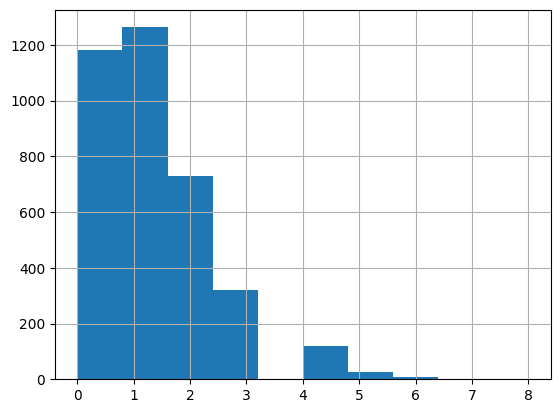

In [5]:
# Daily aggregation:
df['Incident_Count'].value_counts(),   df['Incident_Count'].value_counts(normalize=True), df['Incident_Count'].hist()

In [6]:
df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx", parse_dates = ["Date"], index_col = 'Date')
df.drop(columns = 'Unnamed: 0', inplace =True)
#df_weekly = df['Incident_Count'].resample("W").sum()

#df = df.reset_index()
#df.head(3)

In [7]:
df =df.drop(columns = ['Daily range degC','Grass min °C','Rainfall mm raw incl traces'])

In [8]:

df_weekly = df.resample("W").mean()


In [9]:
df_weekly = df_weekly.reset_index()

In [10]:
#df_weekly = df['Incident_Count'].resample("W")#.sum()
# 2. Resample to weekly (e.g., 'W-SUN' for weeks ending on Sunday)
# Use .sum() for volumes/sales or .mean() for averages


# Use .sum() for volumes/sales or .mean() for averages
#df_weekly = df.resample('W-SUN', on='Date').sum()#.reset_index()
#df_weekly.value_counts(ascending=False)

In [11]:
# Weekly aggregation:
#df_weekly.hist(bins = 9)#,   df_weekly['Incident_Count'].value_counts(normalize=True), df_weekly['Incident_Count'].hist()

In [12]:
df_weekly

,Date,Tmax °C,Tmin °C,Daily Tmean °C,Air frost 0/1,Ground frost 0/1,Max ≥ 25.0°C,Max ≥ 30.0°C,Min ≥ 15.0 °C,Max < 0 °C,Rainfall mm 1 dpl no traces,Rain day (0.2 mm or more),Wet day (1.0 mm or more),Sunshine duration h,Nil sunshine,12 h sunshine,Incident_Count
0,2015-01-04,8.650000,2.500000,5.625000,0.250000,0.500000,0.0,0.0,0.0,0.0,3.875000,1.000000,0.500000,1.625000,0.750000,0.0,1.750000
1,2015-01-11,11.314286,4.114286,7.742857,0.142857,0.428571,0.0,0.0,0.0,0.0,1.800000,0.857143,0.571429,1.957143,0.285714,0.0,1.000000
2,2015-01-18,8.085714,2.000000,5.057143,0.142857,0.714286,0.0,0.0,0.0,0.0,2.728571,0.857143,0.571429,3.257143,0.142857,0.0,1.000000
3,2015-01-25,5.928571,-1.928571,2.028571,0.857143,1.000000,0.0,0.0,0.0,0.0,0.371429,0.285714,0.285714,3.385714,0.142857,0.0,1.142857
4,2015-02-01,7.771429,1.785714,4.800000,0.142857,0.857143,0.0,0.0,0.0,0.0,0.814286,0.571429,0.428571,2.342857,0.142857,0.0,1.571429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,2025-12-07,11.100000,3.185714,7.142857,0.000000,0.428571,0.0,0.0,0.0,0.0,3.814286,1.000000,1.000000,1.957143,0.285714,0.0,1.285714
571,2025-12-14,12.185714,6.357143,9.271429,0.000000,0.285714,0.0,0.0,0.0,0.0,2.014286,0.571429,0.142857,1.828571,0.285714,0.0,1.142857
572,2025-12-21,10.400000,4.242857,7.321429,0.000000,0.285714,0.0,0.0,0.0,0.0,5.128571,1.000000,0.714286,1.814286,0.285714,0.0,1.285714
573,2025-12-28,6.757143,1.985714,4.371429,0.142857,0.428571,0.0,0.0,0.0,0.0,0.014286,0.000000,0.000000,3.257143,0.428571,0.0,0.428571


## 3. Configuration

Change these values to match your data.

In [13]:
# ============================================================
# CONFIGURATION — CHANGE THESE TO MATCH YOUR DATA
# ============================================================

DATE_COLUMN = "Date"          # e.g. "time", "date", "timestamp"
TARGET_COLUMN = "Incident_Count"      # e.g. "sales", "energy_usage", "bookings"
'''
## first choice
WEATHER_COLUMNS = [
    'Tmax °C', 
    'Tmin °C', 
    'Daily Tmean °C', 
    'Ground frost 0/1', 
    'Max < 0 °C',
    'Rainfall mm raw incl traces',
    'Sunshine duration h'
]
'''
## second choice:

WEATHER_COLUMNS = [
     
     'Daily Tmean °C', 
     'Ground frost 0/1', 
     'Max < 0 °C', 
     'Rainfall mm 1 dpl no traces', 
     'Wet day (1.0 mm or more)', 
     'Sunshine duration h'
    ]

# Size of the final chronological test period
TEST_DAYS = 30

# Usually start with "additive".
# Try "multiplicative" if seasonal variation grows as the target grows.
SEASONALITY_MODE = "additive"

# Optional: a separate DataFrame containing future weather forecasts.
# It must include DATE_COLUMN plus every weather feature listed above.
# Leave as None if you only want to evaluate on the held-out test set.

#future_weather_df = None

## 4. Prepare the data for Prophet

In [14]:
required_columns = [DATE_COLUMN, TARGET_COLUMN] + WEATHER_COLUMNS
missing_columns = [col for col in required_columns if col not in df_weekly.columns]

if missing_columns:
    raise ValueError(
        f"These columns are missing from df: {missing_columns}\n"
        f"Available columns: {df.columns.tolist()}"
    )

prophet_df = df_weekly[required_columns].copy()

# Prophet requires these exact names:
# ds = date/timestamp
# y = target to forecast
prophet_df = prophet_df.rename(
    columns={
        DATE_COLUMN: "ds",
        TARGET_COLUMN: "y"
    }
)

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"], errors="coerce")
prophet_df["y"] = pd.to_numeric(prophet_df["y"], errors="coerce")

for col in WEATHER_COLUMNS:
    prophet_df[col] = pd.to_numeric(prophet_df[col], errors="coerce")

# Drop rows without usable date or target values
prophet_df = (
    prophet_df
    .dropna(subset=["ds", "y"])
    .sort_values("ds")
    .reset_index(drop=True)
)

# Prophet expects one row per timestamp
if prophet_df["ds"].duplicated().any():
    duplicate_dates = prophet_df.loc[
        prophet_df["ds"].duplicated(), "ds"
    ].head()

    raise ValueError(
        "Duplicate timestamps found. Aggregate your data first "
        "(for example, one row per day or hour).\n"
        f"Example duplicate timestamps:\n{duplicate_dates}"
    )

if len(prophet_df) < 20:
    raise ValueError(
        "Too little data after cleaning. Prophet needs a longer historical series."
    )

print("Data range:")
print(f"Start: {prophet_df['ds'].min()}")
print(f"End:   {prophet_df['ds'].max()}")
print(f"Rows:  {len(prophet_df)}")

prophet_df.head()

Data range:
Start: 2015-01-04 00:00:00
End:   2026-01-04 00:00:00
Rows:  575


,ds,y,Daily Tmean °C,Ground frost 0/1,Max < 0 °C,Rainfall mm 1 dpl no traces,Wet day (1.0 mm or more),Sunshine duration h
0,2015-01-04,1.750000,5.625000,0.500000,0.0,3.875000,0.500000,1.625000
1,2015-01-11,1.000000,7.742857,0.428571,0.0,1.800000,0.571429,1.957143
2,2015-01-18,1.000000,5.057143,0.714286,0.0,2.728571,0.571429,3.257143
3,2015-01-25,1.142857,2.028571,1.000000,0.0,0.371429,0.285714,3.385714
4,2015-02-01,1.571429,4.800000,0.857143,0.0,0.814286,0.428571,2.342857


## 5. Create a chronological train/test split

Time-series data must not be split randomly. The model is trained on earlier dates and tested on later unseen dates.

In [15]:
#cutoff_date = prophet_df["ds"].max() - pd.Timedelta(days=TEST_DAYS) ## for realtime cuttoff dates
cutoff_date = prophet_df["ds"].max()  - pd.Timedelta(days=len(prophet_df["ds"])*0.2)  ## for our set date range max <=2025
train = prophet_df[prophet_df["ds"] <= cutoff_date].copy()
test = prophet_df[prophet_df["ds"] > cutoff_date].copy()

if train.empty or test.empty:
    raise ValueError(
        "Train or test set is empty. Reduce TEST_DAYS or check your dates."
    )

print("Train period:")
print(f"{train['ds'].min()} to {train['ds'].max()} ({len(train)} rows)")

print("\nTest period:")
print(f"{test['ds'].min()} to {test['ds'].max()} ({len(test)} rows)")

Train period:
2015-01-04 00:00:00 to 2025-09-07 00:00:00 (558 rows)

Test period:
2025-09-14 00:00:00 to 2026-01-04 00:00:00 (17 rows)


## 6. Handle missing weather values

For historical evaluation, interpolation is a practical fallback.

For genuine future production forecasts, use weather forecasts from a weather API or forecast data source rather than filling future weather with averages.

In [16]:
def fill_weather_values(dataframe, weather_columns):
    dataframe = dataframe.copy().sort_values("ds")

    dataframe[weather_columns] = (
        dataframe[weather_columns]
        .interpolate(method="linear", limit_direction="both")
        .ffill()
        .bfill()
    )

    remaining_missing = dataframe[weather_columns].isna().sum()
    remaining_missing = remaining_missing[remaining_missing > 0]

    if not remaining_missing.empty:
        raise ValueError(
            f"Weather columns still contain missing values:\n{remaining_missing}"
        )

    return dataframe


train = fill_weather_values(train, WEATHER_COLUMNS)
test = fill_weather_values(test, WEATHER_COLUMNS)


## 7. Keep only usable weather regressors

Prophet cannot use a regressor that is constant throughout the training data.

In [17]:
valid_weather_columns = []
skipped_weather_columns = []

for col in WEATHER_COLUMNS:
    if train[col].nunique(dropna=True) > 1:
        valid_weather_columns.append(col)
    else:
        skipped_weather_columns.append(col)

if skipped_weather_columns:
    print("Skipping constant weather columns:")
    print(skipped_weather_columns)

print("Weather regressors used:")
print(valid_weather_columns)

Weather regressors used:
['Daily Tmean °C', 'Ground frost 0/1', 'Max < 0 °C', 'Rainfall mm 1 dpl no traces', 'Wet day (1.0 mm or more)', 'Sunshine duration h']


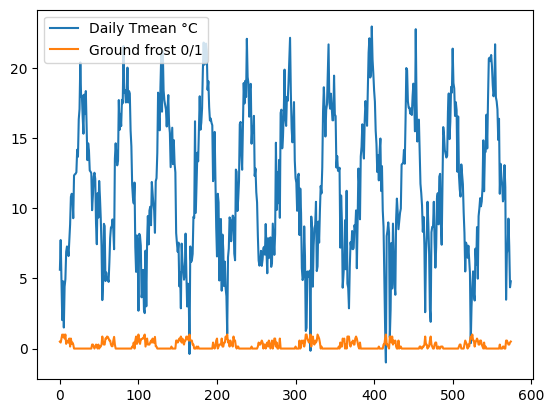

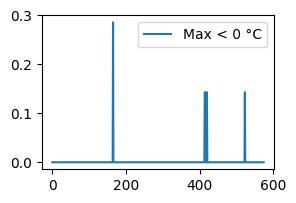

In [18]:
df_weekly[valid_weather_columns][['Daily Tmean °C','Ground frost 0/1']].plot()
plt.figure(figsize =(3,2))

df_weekly[valid_weather_columns]['Max < 0 °C'].plot()

plt.legend()
plt.show()

## 8. Build and fit Prophet

In [19]:
def build_prophet_model(regressors):
    model = Prophet(
        seasonality_mode=SEASONALITY_MODE,
        yearly_seasonality="auto",
        weekly_seasonality="auto",
        daily_seasonality="auto",
        interval_width=0.95
    )

    for regressor in regressors:
        model.add_regressor(regressor)

    return model


model = build_prophet_model(valid_weather_columns)

train_columns = ["ds", "y"] + valid_weather_columns
model.fit(train[train_columns])

17:22:06 - cmdstanpy - INFO - Chain [1] start processing
17:22:06 - cmdstanpy - INFO - Chain [1] done processing


## 9. Forecast the held-out test set

The target `y` is deliberately excluded from the future DataFrame so this acts like a genuine forecast.

For the historical test set, it is valid to use the actual weather that occurred. For a real future forecast, you need forecast weather values instead.

In [22]:
test_future = test[["ds"] + valid_weather_columns].copy()

forecast_test = model.predict(test_future)

results = test[["ds", "y"]].merge(
    forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="left"
)

results.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2025-09-14,1.571429,1.278881,0.480733,2.142055
1,2025-09-21,0.571429,1.153880,0.285731,1.970227
2,2025-09-28,0.428571,1.228533,0.335171,1.988804
3,2025-10-05,0.857143,1.191837,0.381958,2.058048
4,2025-10-12,0.714286,1.081452,0.234180,1.910035


## 10. Evaluate performance

In [23]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = denominator != 0

    return np.mean(
        np.abs(y_true[valid] - y_pred[valid]) / denominator[valid]
    ) * 100


mae = mean_absolute_error(results["y"], results["yhat"])
rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))
smape_score = smape(results["y"], results["yhat"])

# Naive benchmark: predicts the final training value for every test row
naive_predictions = np.repeat(train["y"].iloc[-1], len(test))
naive_mae = mean_absolute_error(test["y"], naive_predictions)
naive_rmse = np.sqrt(mean_squared_error(test["y"], naive_predictions))

metrics = pd.DataFrame({
    "Model": ["Prophet + weather", "Naive baseline"],
    "MAE": [mae, naive_mae],
    "RMSE": [rmse, naive_rmse],
    "sMAPE (%)": [smape_score, np.nan]
})

print(metrics.round(3))

results.to_csv("prophet_test_predictions.csv", index=False)
print("\nSaved test predictions to: prophet_test_predictions.csv")

               Model    MAE   RMSE  sMAPE (%)
0  Prophet + weather  0.464  0.505     43.793
1     Naive baseline  0.353  0.441        NaN

Saved test predictions to: prophet_test_predictions.csv


## 11. Plot actual versus predicted values

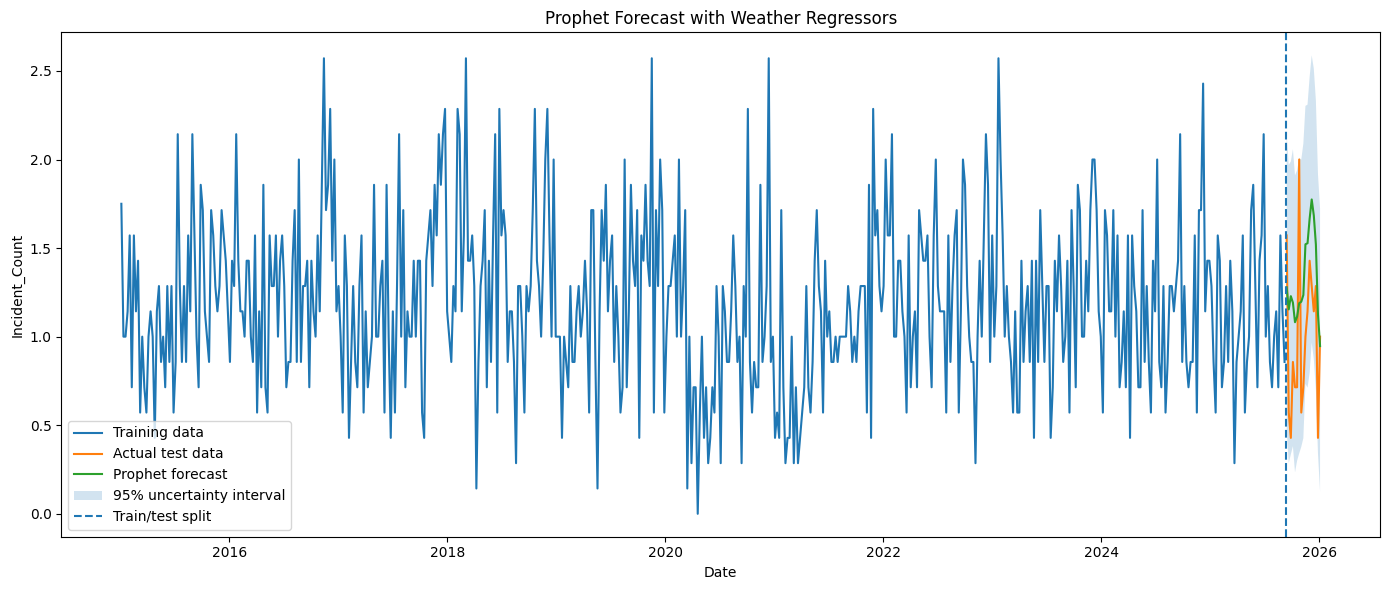

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(train["ds"], train["y"], label="Training data")
plt.plot(test["ds"], test["y"], label="Actual test data")
plt.plot(results["ds"], results["yhat"], label="Prophet forecast")

plt.fill_between(
    results["ds"],
    results["yhat_lower"],
    results["yhat_upper"],
    alpha=0.2,
    label="95% uncertainty interval"
)

plt.axvline(
    cutoff_date,
    linestyle="--",
    label="Train/test split"
)

plt.title("Prophet Forecast with Weather Regressors")
plt.xlabel("Date")
plt.ylabel(TARGET_COLUMN)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Inspect model components

This shows the learned trend, seasonal patterns, and the effects of any configured components.

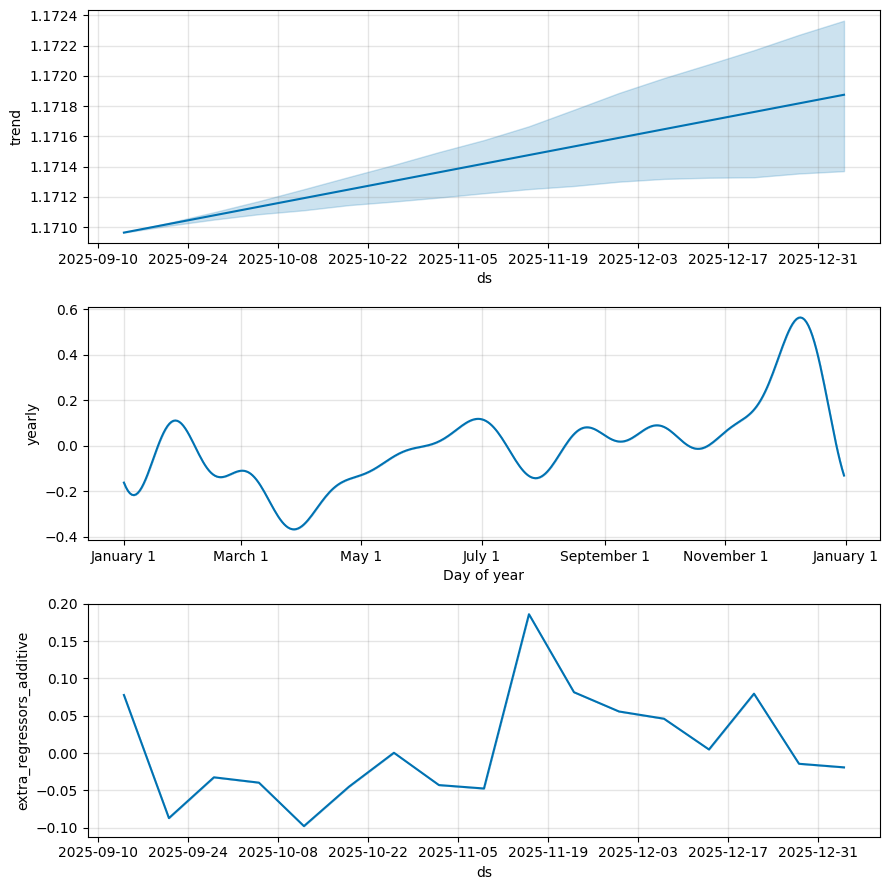

In [25]:
model.plot_components(forecast_test)
plt.tight_layout()
plt.show()

## 13. Optional: Forecast future dates with weather forecasts

Set `future_weather_df` in the configuration section. It must contain the date column and all weather columns used by the model.

Example:

```python
future_weather_df = pd.read_csv("future_weather_forecast.csv")
```

Do not use unknown future observed weather when making real production forecasts. Use weather forecasts.

In [30]:

df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx")
df.drop(columns = 'Unnamed: 0', inplace =True)
df.head(3)
#df = df[df['Date']>='2025-01-01']

future_weather_df = df.copy()

if future_weather_df is not None:

    full_data = fill_weather_values(prophet_df, WEATHER_COLUMNS)

    final_model = build_prophet_model(valid_weather_columns)
    final_model.fit(full_data[["ds", "y"] + valid_weather_columns])

    future_weather = future_weather_df.copy()

    if DATE_COLUMN not in future_weather.columns:
        raise ValueError(
            f"future_weather_df must contain '{DATE_COLUMN}'."
        )

    missing_future_weather = [
        col for col in valid_weather_columns
        if col not in future_weather.columns
    ]

    if missing_future_weather:
        raise ValueError(
            f"future_weather_df is missing: {missing_future_weather}"
        )

    future_weather = future_weather.rename(columns={DATE_COLUMN: "ds"})
    future_weather["ds"] = pd.to_datetime(
        future_weather["ds"],
        errors="coerce"
    )

    for col in valid_weather_columns:
        future_weather[col] = pd.to_numeric(
            future_weather[col],
            errors="coerce"
        )

    future_weather = future_weather.dropna(
        subset=["ds"] + valid_weather_columns
    ).sort_values("ds")

    # Keep only dates after the final historical observation
    future_weather = future_weather[
        future_weather["ds"] > full_data["ds"].max()
    ].copy()

    if future_weather.empty:
        raise ValueError(
            "No future dates found in future_weather_df."
        )

    production_forecast = final_model.predict(
        future_weather[["ds"] + valid_weather_columns]
    )

    production_output = production_forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].copy()

    production_output.to_csv(
        "prophet_future_forecast.csv",
        index=False
    )

    print("Saved future forecast to: prophet_future_forecast.csv")
    display(production_output)#.head())

else:
    print(
        "future_weather_df is None, so no genuine future forecast was created."
    )

17:25:07 - cmdstanpy - INFO - Chain [1] start processing
17:25:07 - cmdstanpy - INFO - Chain [1] done processing


ValueError: No future dates found in future_weather_df.

In [ ]:
production_output

In [ ]:
df_2025_prod = df_2025 = production_output.set_index("ds")
df_2025_prod['yhat'].plot()


In [ ]:
#df = df.set_index("Date")

NameError: name 'df_2025_prod' is not defined

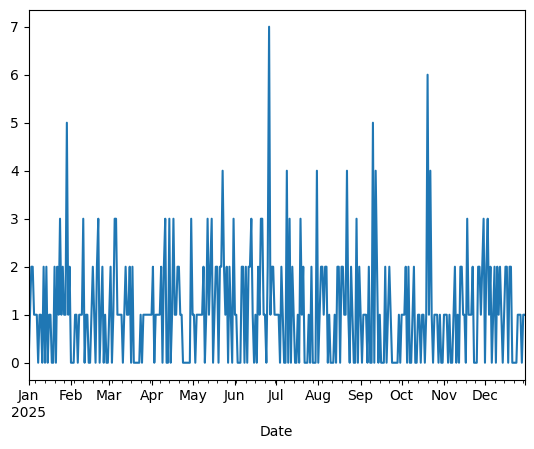

In [31]:
df_2025 = df[df["Date"]>='20250101'].set_index("Date")
df_2025['Incident_Count'].plot()
df_2025_prod['yhat'].plot()
#df_2025_prod['yhat_lower'].plot()
#df_2025_prod['yhat_upper'].plot()